In [1]:
import xarray as xr
import numpy as np
import functions
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from global_land_mask import globe
import glob

import warnings
warnings.filterwarnings('ignore')

# Temporal and spatial defintions

In [2]:
Arctic_limit = 60
land_longitudes = slice(0,300) # Exclude Greenland
spring_summer_months = [3, 4, 5, 6, 7, 8]
spring_summer_label = 'MAMJJA'
summer_months = [6, 7, 8]

# Significance level
alpha=0.05

# Observational data

In [3]:
rpath = '/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/data/'
start_year = 2003
end_year = 2025

## Extract data and calculate spatial averages

### Snow cover data

Url: https://www.ncei.noaa.gov/access/metadata/landing-page/bin/iso?id=gov.noaa.ncdc:C00756

Robinson, David A.; Estilow, Thomas W.; and NOAA CDR Program (2012): NOAA Climate Data Record (CDR) of Northern Hemisphere (NH) Snow Cover Extent (SCE), Version 1. NOAA National Centers for Environmental Information. doi:10.7289/V5N014G9 [20.02.2026].

In [4]:
sce = xr.open_dataset(rpath+'nhsce_v01r01_19661004_20260202.nc')

# Select times with meaningful data
sce = sce.sel(time=slice('1975-01-01','2026-01-01'))

# Select area
land_weights = sce.land # Extract land weights
latitude_weights = sce.latitude >= Arctic_limit # Select latitudes
longitude_weights = 1-(sce.longitude >= -60)*(sce.longitude <=0) # Select longitudes, i.e. longitudes between 0 and 300 degrees east
total_weights = land_weights*longitude_weights*latitude_weights # Create weights that include all selected land areas

# Calculate area-weighted average snow cover extent across area
area_weights = sce.area
total_weights_area = (area_weights*total_weights)
total_area = total_weights_area.sum() # Find total area sum for seleced grid boxes
snow_cover_extent = (sce['snow_cover_extent']*total_weights_area/total_area).sum(('y','x'))

#Convert from fraction to percentage
snow_cover_extent = snow_cover_extent*100

### Soil moisture data

In [5]:
SM_ERA5 = xr.open_dataset(rpath+'SM_ERA5_1970_2025_10cm_20cm.nc')

# Convert units from m3/m3 to kg/m2
SM_ERA5_converted = SM_ERA5['swvl_10cm']*100 # Conversion factor = 1000 kg/m3 * 0.10 m

# Calculate area-weighted regional average
SM_ERA5 = functions.computeWeightedMean(SM_ERA5_converted.sel(lon=land_longitudes))

### Cloud cover data

In [6]:
CERES  = xr.open_dataset(rpath+'CERES_EBAF-TOA_Ed4.2.1_Subset_200003-202512.nc')

ds = CERES.copy()
# Convert CERES longitudes to match land mask 
ds.coords['lon']= (ds.coords['lon'] + 180) % 360- 180
ds = ds.sortby(ds.lon)

# Get land mask for CERES grid
lats = ds.lat.expand_dims(dims=len(ds.lon)).T
lons = ds.lon.expand_dims(dims=len(ds.lat))
landmask = globe.is_land(lats, lons)
landmask = xr.DataArray(landmask, dims = ["lat","lon"], coords=dict(lat=ds.lat, lon=ds.lon))

# Regrid land mask to original CERES data
lons = np.array(landmask.lon)
lons[np.where(lons<0)] = 360 + lons[np.where(lons<0)]
landmask.coords['lon']= lons
landmask = landmask.sortby(landmask.lon)

# Calculate area-weighted regional average using land mask
cloud_cover = functions.computeWeightedMeanMasked(   CERES['cldarea_total_daynight_mon'].sel(lat=slice(Arctic_limit, 90),lon=land_longitudes), 
                                                                                landmask.sel(lat=slice(Arctic_limit, 90),lon=land_longitudes))


### Global temperature data

In [8]:
temp_ERA5 = xr.open_dataset(rpath+'ERA5_2m_temperature_global.nc')
temp_ERA5 = temp_ERA5.rename({'latitude':'lat', 'longitude':'lon', 'valid_time':'time'})
temp_ERA5 = temp_ERA5.reindex(lat=list(reversed(temp_ERA5.lat)))

temp_ERA5_global = functions.computeWeightedMean(temp_ERA5['t2m'])

### Arctic land temperature data

In [7]:
temp_ERA5_JJA = xr.open_dataset(rpath+'temperature2m_ERA5_JJA_annual.nc')
temp_ERA5_JJA_land = temp_ERA5_JJA['t2m']

## Calculate temporal averages

In [8]:
# Snow cover extent

sce_season = snow_cover_extent.sel(time = snow_cover_extent['time.month'].isin(spring_summer_months))
sce_season = sce_season.groupby(sce_season['time.year']).mean('time')

# Soil moisture ERA5-Land

SM_ERA5_season = SM_ERA5.sel(time = SM_ERA5['time.month'].isin(summer_months))
SM_ERA5_season = SM_ERA5_season.groupby(SM_ERA5_season['time.year']).mean('time')

# Cloud cover

cc_season = cloud_cover.sel(time = cloud_cover['time.month'].isin(summer_months))
cc_season = cc_season.groupby(cc_season['time.year']).mean('time')

# Global mean 2m air temperature

#temp_ERA5_annual = temp_ERA5_global.groupby('time.year').mean('time')
temp_ERA5_annual = temp_ERA5_JJA_land

In [19]:
# Define time period
timeslice_trend=slice(start_year,end_year)

T_slope_global, _, _, _ = stats.theilslopes(temp_ERA5_annual.sel(year=timeslice_trend), alpha=alpha)
T_slope_local, _, _, _ = stats.theilslopes(temp_ERA5_JJA_land.sel(year=timeslice_trend), alpha=alpha)

In [20]:
T_slope_local/T_slope_global

np.float64(1.8798453336959646)

## Calculate regression coefficient with respect to temperature and confidence intervals

In [9]:
# Define time period
timeslice_trend=slice(start_year,end_year)

# Create linear regression

snow_slope, snow_intercept, snow_minus, snow_plus = stats.theilslopes(sce_season.sel(year=timeslice_trend), temp_ERA5_annual.sel(year=timeslice_trend), alpha=alpha)

CERES_slope, CERES_intercept, CERES_minus, CERES_plus = stats.theilslopes(cc_season.sel(year=timeslice_trend), temp_ERA5_annual.sel(year=timeslice_trend), alpha=alpha)

SM_ERA5_slope, SM_ERA5_intercept, SM_ERA5_minus, SM_ERA5_plus = stats.theilslopes(SM_ERA5_season.sel(year=timeslice_trend), temp_ERA5_annual.sel(year=timeslice_trend), alpha=alpha)

# Normalize slope values to initial value to get percentage change per year

snow_slope_rel = snow_slope/sce_season.sel(year=start_year).values*100
snow_yerr_minus = abs(snow_minus/sce_season.sel(year=start_year).values*100 - snow_slope_rel)
snow_yerr_plus = abs(snow_plus/sce_season.sel(year=start_year).values*100 - snow_slope_rel)

CERES_slope_rel = CERES_slope/cc_season.sel(year=start_year).values*100
CERES_yerr_minus = abs(CERES_minus/sce_season.sel(year=start_year).values*100 - CERES_slope_rel)
CERES_yerr_plus = abs(CERES_plus/sce_season.sel(year=start_year).values*100 - CERES_slope_rel)

SM_ERA5_slope_rel = SM_ERA5_slope/SM_ERA5_season.sel(year=start_year).values*100
SM_ERA5_yerr_minus = abs(SM_ERA5_minus/SM_ERA5_season.sel(year=start_year).values*100 - SM_ERA5_slope_rel)
SM_ERA5_yerr_plus = abs(SM_ERA5_plus/SM_ERA5_season.sel(year=start_year).values*100 - SM_ERA5_slope_rel)

## Model data

In [10]:
rpath = '/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/data/'
timeslice=slice('2040-01-01','2069-12-31')

In [12]:
ds_piClim_clm = xr.open_dataset(rpath+'N1850_f19_tn14_noresm2_3_slf_output_20250529.clm.concatfiles.nc')
ds_2xCO2_clm = xr.open_dataset(rpath+'N1850_f19_tn14_noresm2_3_slf_output_2xCO2_20250529.clm.concatfiles.nc')
ds_4xCO2_clm = xr.open_dataset(rpath+'N1850_f19_tn14_noresm2_3_slf_output_4xCO2_20250529.clm.concatfiles.nc')

# Fix time stamp
ds_piClim_clm = functions.fix_clm_time(ds_piClim_clm)
ds_2xCO2_clm = functions.fix_clm_time(ds_2xCO2_clm)
ds_4xCO2_clm = functions.fix_clm_time(ds_4xCO2_clm)

# Select timeslice variables
ds_piClim_clm = ds_piClim_clm.sel(time=timeslice)
ds_2xCO2_clm = ds_2xCO2_clm.sel(time=timeslice)
ds_4xCO2_clm = ds_4xCO2_clm.sel(time=timeslice)

# Select variables
ds_piClim_clm = ds_piClim_clm[['area','SOILICE', 'SOILLIQ', 'FSNO']]
ds_2xCO2_clm = ds_2xCO2_clm[['area','SOILICE', 'SOILLIQ', 'FSNO']]
ds_4xCO2_clm = ds_4xCO2_clm[['area','SOILICE', 'SOILLIQ', 'FSNO']]

ds_clm = xr.concat([ds_piClim_clm, ds_2xCO2_clm, ds_4xCO2_clm], dim='co2_conc')
ds_clm = ds_clm.assign_coords({'co2_conc':['piClim', '2xCO2', '4xCO2']})

# Calculate correct soil moisture
tmp = ds_clm['SOILICE'] + ds_clm['SOILLIQ']
tmp = tmp.sel(levsoi=0) + tmp.sel(levsoi=1) + 2/3*tmp.sel(levsoi=2)
ds_clm['SOILWATER_10CM_corrected'] = tmp

ds_clm = ds_clm.drop_vars(['SOILICE', 'SOILLIQ'])

In [11]:
ds_cloud_piClim = xr.open_dataset(rpath+'other_cloud_vars/CLDTOT_piClim.nc')
ds_cloud_2xCO2 = xr.open_dataset(rpath+'other_cloud_vars/CLDTOT_abrupt-2xCO2.nc')
ds_cloud_4xCO2 = xr.open_dataset(rpath+'other_cloud_vars/CLDTOT_abrupt-4xCO2.nc')

ds_cloud_piClim = ds_cloud_piClim.sel(time=timeslice)
ds_cloud_2xCO2 = ds_cloud_2xCO2.sel(time=timeslice)
ds_cloud_4xCO2 = ds_cloud_4xCO2.sel(time=timeslice)

ds_cloud = xr.concat([ds_cloud_piClim, ds_cloud_2xCO2, ds_cloud_4xCO2], dim='co2_conc')
ds_cloud = ds_cloud.assign_coords({'co2_conc':['piClim', '2xCO2', '4xCO2']})

files = glob.glob(rpath+'feedback_input/interval30/tas_piClim*.nc')
files.sort()
ds_tas_piClim = xr.open_mfdataset(files)
ds_tas_2xCO2 = xr.open_dataset(rpath+'feedback_input/tas_abrupt-2xCO2_1920-01-01_2069-12-31.nc')
ds_tas_4xCO2 = xr.open_dataset(rpath+'feedback_input/tas_abrupt-4xCO2_1920-01-01_2069-12-31.nc')

ds_tas_piClim = ds_tas_piClim.sel(time=timeslice)
ds_tas_2xCO2 = ds_tas_2xCO2.sel(time=timeslice)
ds_tas_4xCO2 = ds_tas_4xCO2.sel(time=timeslice)

ds_tas = xr.concat([ds_tas_piClim, ds_tas_2xCO2, ds_tas_4xCO2], dim='co2_conc')
ds_tas = ds_tas.assign_coords({'co2_conc':['piClim', '2xCO2', '4xCO2']})

# Get land mask

landmask = xr.open_dataset(rpath+'other_cloud_vars/LANDFRAC_piClim.nc')
landmask = landmask['LANDFRAC'].isel(time=0)


In [13]:
# Create Arctic averages over land excluding greenland

area_weights = ds_clm['area'].sel(lat=slice(Arctic_limit,90),lon=land_longitudes, co2_conc='piClim')/((ds_clm['area'].sel(lat=slice(Arctic_limit,90),lon=land_longitudes, co2_conc='piClim')).sum())

# Calculate Arctic averages
ds_clm_Arctic = (ds_clm.sel(lat=slice(Arctic_limit,90), lon=land_longitudes)*area_weights).sum(dim=['lon','lat'])
ds_cloud_Arctic = functions.computeWeightedMeanMasked(ds_cloud.sel(lat=slice(Arctic_limit, 90),lon=land_longitudes), landmask.sel(lat=slice(Arctic_limit, 90),lon=land_longitudes))
#ds_tas_Arctic = functions.computeWeightedMeanMasked(ds_tas.sel(lat=slice(Arctic_limit, 90),lon=land_longitudes), landmask.sel(lat=slice(Arctic_limit, 90),lon=land_longitudes))

# Calculate global averages
#ds_tas_global = functions.computeWeightedMean(ds_tas)
ds_tas_global = functions.computeWeightedMeanMasked(ds_tas.sel(lat=slice(Arctic_limit, 90),lon=land_longitudes), landmask.sel(lat=slice(Arctic_limit, 90),lon=land_longitudes))


ds_spatavg = xr.merge([ds_clm_Arctic,ds_cloud_Arctic, ds_tas_global])

In [36]:
da_tas_Arctic_JJA = ds_tas_Arctic['tas'].sel(time = ds_tas_Arctic['time.month'].isin(summer_months))
da_tas_Arctic_JJA = da_tas_Arctic_JJA.groupby(da_tas_Arctic_JJA['time.year']).mean('time')

In [20]:
# Create temporal averages
da_list = []
for var in ['CLDTOT', 'FSNO', 'SOILWATER_10CM_corrected', 'tas']:

    if var in ['CLDTOT', 'SOILWATER_10CM_corrected']:
    # Select summer months
        da = ds_spatavg[var].sel(time = ds_spatavg['time.month'].isin(summer_months))
        da = da.groupby(da['time.year']).mean('time')
    
    elif var == 'FSNO':
    # Select spring and summer months
        da = ds_spatavg[var].sel(time = ds_spatavg['time.month'].isin(spring_summer_months))
        da = da.groupby(da['time.year']).mean('time')
    
    elif var == 'tas':
    # Select whole year
        #da = ds_spatavg[var].groupby(ds_spatavg['time.year']).mean('time')
        da = ds_spatavg[var].sel(time = ds_spatavg['time.month'].isin(summer_months))
        da = da.groupby(da['time.year']).mean('time')
    
    da_list.append(da)

ds_avg = xr.merge(da_list)

In [37]:
da_tas_Arctic_JJA.sel(co2_conc=exp)

<xarray.DataArray 'tas' (year: 30)> Size: 240B
dask.array<getitem, shape=(30,), dtype=float64, chunksize=(1,), chunktype=numpy.ndarray>
Coordinates:
  * year      (year) int64 240B 2040 2041 2042 2043 2044 ... 2066 2067 2068 2069
    co2_conc  <U6 24B '4xCO2'
Attributes:
    units:         K
    long_name:     Reference height temperature
    cell_methods:  time: mean

In [41]:
for exp in ['2xCO2', '4xCO2']:
    delta_abs = da_tas_Arctic_JJA.sel(co2_conc=exp).mean('year') - (da_tas_Arctic_JJA.sel(co2_conc='piClim')).mean('year')
    delta_abs_glob = ds_avg['tas'].sel(co2_conc=exp).mean('year') - (ds_avg['tas'].sel(co2_conc='piClim')).mean('year')
    print(delta_abs.values/delta_abs_glob.values)

1.6901293615473223
1.996406245742865


In [21]:
# Compute absolute changes
delta_abs = ds_avg - ds_avg.sel(co2_conc='piClim')

# Compute relative changes
delta_rel = delta_abs*100/ds_avg.sel(co2_conc='piClim').mean('year')

# Compute absolute changes with respect to temperature
delta_abs_delta_T = delta_abs/(delta_abs['tas'])

# Compute rel changes with respect to temperature
delta_rel_delta_T = delta_rel/(delta_abs['tas'])

In [22]:
# Calculate mean change

delta_abs_delta_T_mean = delta_abs_delta_T.mean('year')
delta_rel_delta_T_mean = delta_rel_delta_T.mean('year')

In [23]:
# Calculate quantiles

upper_bounds = abs(delta_abs_delta_T.quantile(q=1-alpha/2, dim='year') - delta_abs_delta_T_mean)
lower_bounds = abs(delta_abs_delta_T.quantile(q=alpha/2, dim='year') - delta_abs_delta_T_mean)

upper_bounds_rel = abs(delta_rel_delta_T.quantile(q=1 - alpha/2, dim='year') - delta_rel_delta_T_mean)
lower_bounds_rel = abs(delta_rel_delta_T.quantile(q=alpha/2, dim='year') - delta_rel_delta_T_mean)

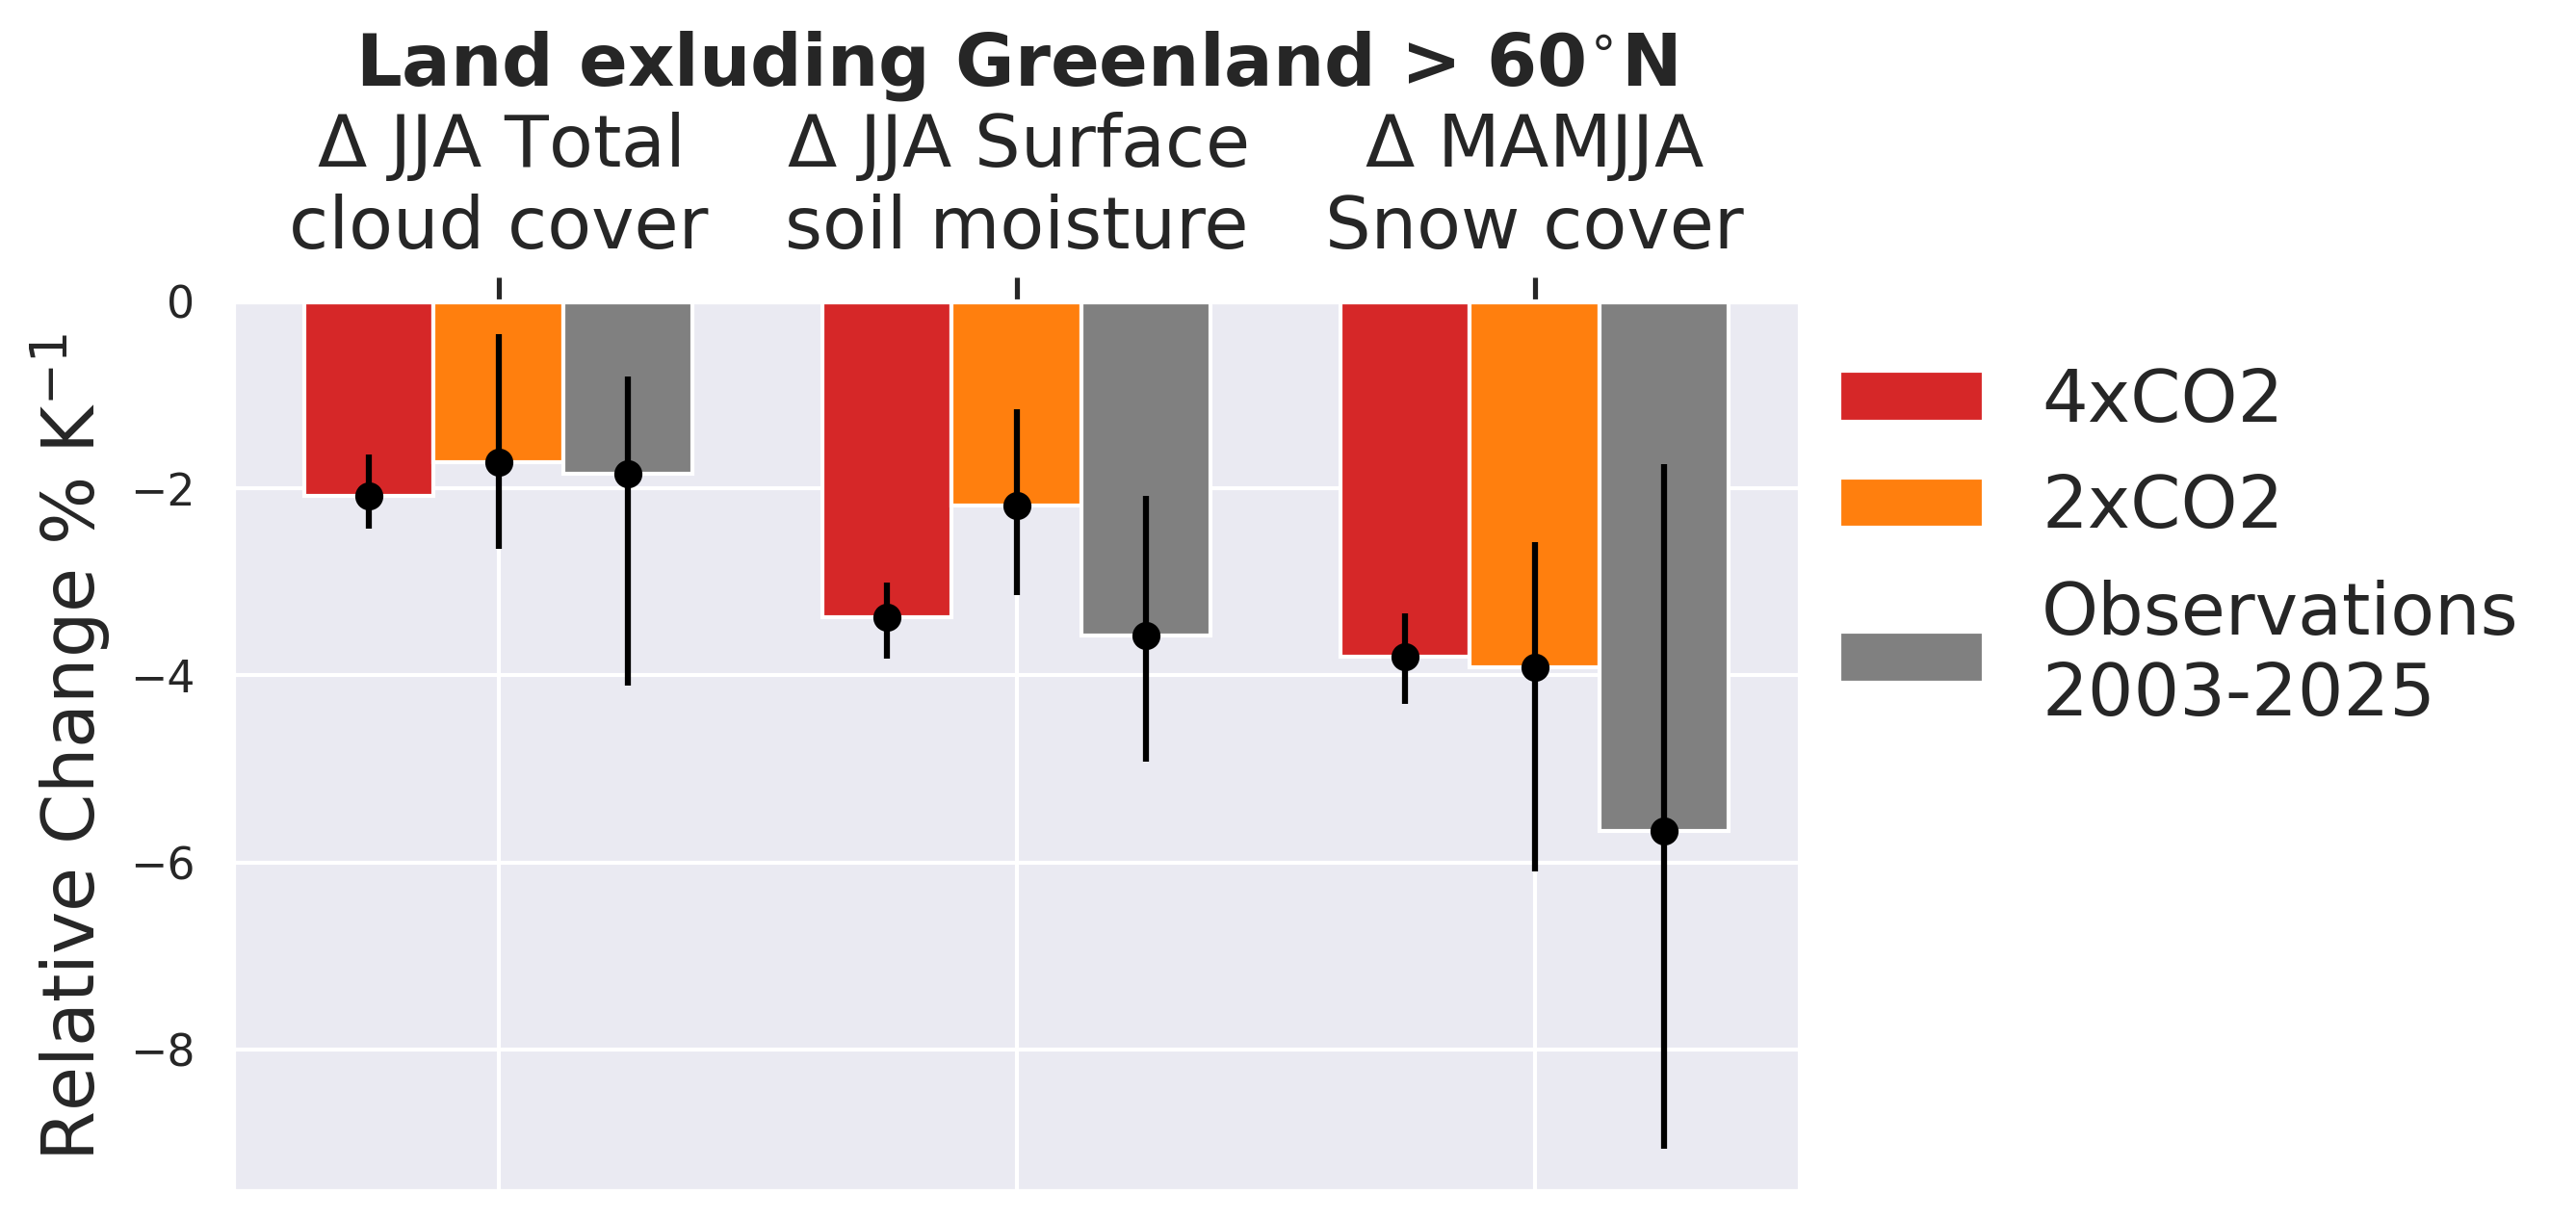

In [24]:
sns.set_theme()
fig, ax = plt.subplots(1, 1, figsize=[7, 4], dpi=300)

vars = ['$\Delta$ JJA Total\ncloud cover', '$\Delta$ JJA Surface\nsoil moisture', '$\Delta$ '+spring_summer_label+'\nSnow cover']
JJA_change = {
    '4xCO2':                    [delta_rel_delta_T_mean['CLDTOT'].sel(co2_conc='4xCO2'),
                                 delta_rel_delta_T_mean['SOILWATER_10CM_corrected'].sel(co2_conc='4xCO2'),
                                 delta_rel_delta_T_mean['FSNO'].sel(co2_conc='4xCO2')],

    '2xCO2':                    [delta_rel_delta_T_mean['CLDTOT'].sel(co2_conc='2xCO2'),
                                 delta_rel_delta_T_mean['SOILWATER_10CM_corrected'].sel(co2_conc='2xCO2'),
                                 delta_rel_delta_T_mean['FSNO'].sel(co2_conc='2xCO2')],
    
    'Observations\n2003-2025':  [CERES_slope_rel,
                                 SM_ERA5_slope_rel,
                                 snow_slope_rel],
                                }

errors = [[(lower_bounds_rel['CLDTOT'].sel(co2_conc='4xCO2'), lower_bounds_rel['SOILWATER_10CM_corrected'].sel(co2_conc='4xCO2'), lower_bounds_rel['FSNO'].sel(co2_conc='4xCO2')),
           (upper_bounds_rel['CLDTOT'].sel(co2_conc='4xCO2'), upper_bounds_rel['SOILWATER_10CM_corrected'].sel(co2_conc='4xCO2'), upper_bounds_rel['FSNO'].sel(co2_conc='4xCO2'))],
          [(lower_bounds_rel['CLDTOT'].sel(co2_conc='2xCO2'), lower_bounds_rel['SOILWATER_10CM_corrected'].sel(co2_conc='2xCO2'), lower_bounds_rel['FSNO'].sel(co2_conc='2xCO2')),
           (upper_bounds_rel['CLDTOT'].sel(co2_conc='2xCO2'), upper_bounds_rel['SOILWATER_10CM_corrected'].sel(co2_conc='2xCO2'), upper_bounds_rel['FSNO'].sel(co2_conc='2xCO2'))],
          [(CERES_yerr_minus, SM_ERA5_yerr_minus, snow_yerr_minus),
           (CERES_yerr_plus, SM_ERA5_yerr_plus, snow_yerr_plus)]
          ]

x = np.arange(len(vars))  # the label locations
width = 0.25  # the width of the bars
multiplier = 0
colors = ['tab:red', 'tab:orange','grey']
for exp, measurement in JJA_change.items():
    offset = width * multiplier
    rects = ax.bar(x + offset, measurement, width, label=exp, color=colors[multiplier])
    errorbars = ax.errorbar(x + offset, measurement, yerr=errors[multiplier], fmt="o", color="black")
    multiplier += 1

ax.set_xticks(x + width, vars, fontsize=18)
ax.xaxis.tick_top()
ax.set_ylabel('Relative Change % K$^{-1}$', fontsize=18)
ax.legend(loc='upper right', fontsize=18,bbox_to_anchor=[1.5,1],frameon=False)
ax.set_title('Land exluding Greenland > 60$^{\circ}$N',fontsize=18, fontweight='bold')

fig.savefig('/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/arctic-cloud-feedbacks/article_figs/Fig5_local.png',bbox_inches='tight')
fig.savefig('/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/arctic-cloud-feedbacks/article_figs/Fig5_local.pdf',bbox_inches='tight')